In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Load datasets

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

investor = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
# Convert date columns

nav["date"] = pd.to_datetime(nav["date"])

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

portfolio["portfolio_date"] = pd.to_datetime(
    portfolio["portfolio_date"]
)

print("Date columns converted successfully!")

Date columns converted successfully!


In [4]:
print(nav.shape)
print(investor.shape)
print(fund_master.shape)
print(portfolio.shape)

(46000, 3)
(32778, 13)
(40, 15)
(322, 8)


In [5]:
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [6]:
# Sort by Fund and Date

nav = nav.sort_values(["amfi_code", "date"])

# Daily Return

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [7]:
# Historical VaR (95%) and CVaR

risk_metrics = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # 95% Historical VaR (5th percentile)
    var95 = np.percentile(returns, 5)

    # CVaR = Average of returns below VaR
    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "amfi_code": code,
        "VaR_95": round(var95, 4),
        "CVaR_95": round(cvar95, 4)
    })

risk_metrics = pd.DataFrame(risk_metrics)

risk_metrics.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.0144,-0.0181
1,100025,-0.0038,-0.0050
2,100033,-0.0190,-0.0235
3,101206,-0.0133,-0.0174
4,101207,-0.0260,-0.0325


In [8]:
risk_metrics = risk_metrics.sort_values("VaR_95")

risk_metrics.head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.0269,-0.0324
17,119095,-0.0262,-0.0317
4,101207,-0.0260,-0.0325
11,118634,-0.0254,-0.0323
21,119598,-0.0245,-0.0306
39,149324,-0.0235,-0.0310
7,102886,-0.0192,-0.0233
2,100033,-0.0190,-0.0235
25,120505,-0.0189,-0.0243
16,119094,-0.0185,-0.0243


In [9]:
risk_metrics.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [10]:
# Load Fund Scorecard

fund_scorecard = pd.read_csv("../reports/fund_scorecard.csv")

top5_codes = fund_scorecard.head(5)["amfi_code"].tolist()

print(top5_codes)

[148567, 120843, 120505, 100033, 120504]


In [11]:
# Filter Top 5 Funds

top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav.shape

(5750, 4)

In [12]:
# Rolling 90-Day Sharpe Ratio

top5_nav["Rolling_Sharpe"] = (
    top5_nav.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

top5_nav.head(100)

,amfi_code,date,nav,daily_return,Rolling_Sharpe
2300,100033,2022-01-03,107.3758,NaN,NaN
2301,100033,2022-01-04,105.9447,-0.013328,NaN
2302,100033,2022-01-05,105.4800,-0.004386,NaN
2303,100033,2022-01-06,104.9350,-0.005167,NaN
2304,100033,2022-01-07,104.3318,-0.005748,NaN
...,...,...,...,...,...
2395,100033,2022-05-16,94.8770,0.000373,-1.432745
2396,100033,2022-05-17,95.6569,0.008220,-1.329065
2397,100033,2022-05-18,97.6478,0.020813,-0.956879
2398,100033,2022-05-19,98.0226,0.003838,-0.942304


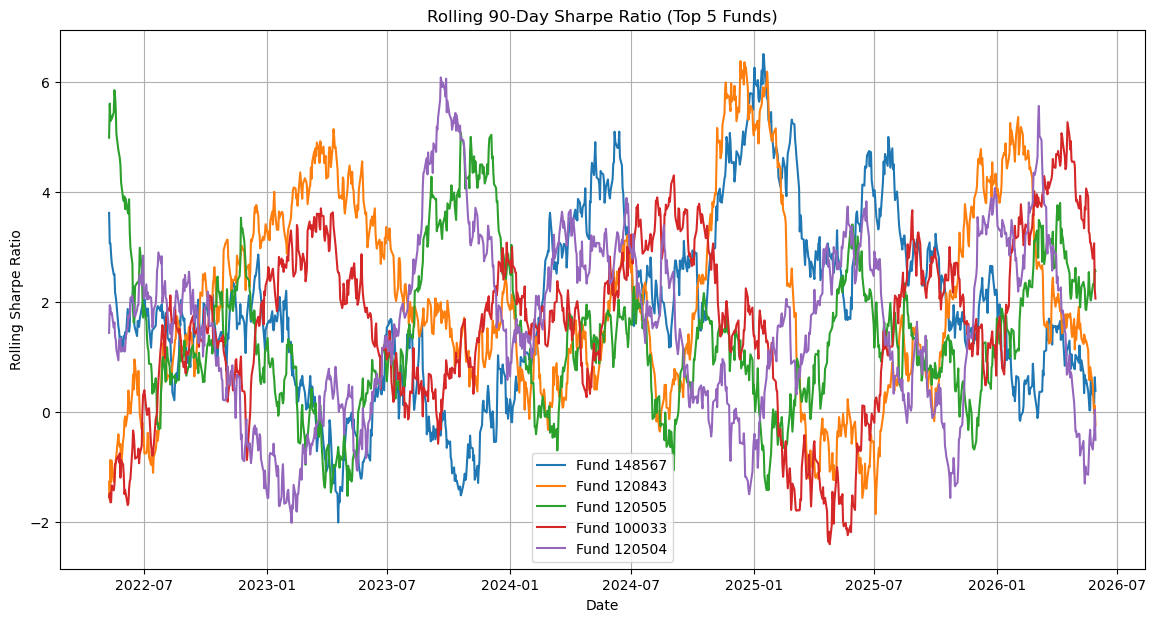

In [13]:
plt.figure(figsize=(14, 7))

for code in top5_codes:
    fund = top5_nav[top5_nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["Rolling_Sharpe"],
        label=f"Fund {code}"
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Find first transaction date for each investor

first_transaction = (
    investor.groupby("investor_id")["transaction_date"]
            .min()
            .reset_index()
)

first_transaction.rename(
    columns={"transaction_date": "first_transaction_date"},
    inplace=True
)

first_transaction.head()

,investor_id,first_transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [15]:
# Extract Cohort Year

first_transaction["cohort_year"] = (
    first_transaction["first_transaction_date"].dt.year
)

first_transaction.head()

,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [16]:
# Merge cohort year into investor dataset

investor = investor.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [17]:
# Filter only SIP transactions

sip_data = investor[investor["transaction_type"] == "SIP"]

cohort_summary = (
    sip_data.groupby("cohort_year")
            .agg(
                Average_SIP_Amount=("amount_inr", "mean"),
                Total_Invested=("amount_inr", "sum"),
                SIP_Transactions=("amount_inr", "count")
            )
            .reset_index()
)

cohort_summary["Average_SIP_Amount"] = cohort_summary["Average_SIP_Amount"].round(2)

cohort_summary

,cohort_year,Average_SIP_Amount,Total_Invested,SIP_Transactions
0,2024,10996.89,214978121,19549
1,2025,13505.21,2255370,167


In [18]:
# Most preferred fund in each cohort

top_fund = (
    sip_data.groupby(["cohort_year", "amfi_code"])
            .size()
            .reset_index(name="Count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "Count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,Count
24,2024,120504,536
62,2025,119599,8


In [19]:
# Add Scheme Name

top_fund = top_fund.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund

,cohort_year,amfi_code,Count,scheme_name
0,2024,120504,536,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,119599,8,SBI Small Cap Fund - Direct Plan - Growth


In [20]:
# Final Cohort Analysis

cohort_analysis = cohort_summary.merge(
    top_fund[["cohort_year", "scheme_name"]],
    on="cohort_year",
    how="left"
)

cohort_analysis.rename(
    columns={
        "scheme_name": "Top_Fund_Preference"
    },
    inplace=True
)

cohort_analysis

,cohort_year,Average_SIP_Amount,Total_Invested,SIP_Transactions,Top_Fund_Preference
0,2024,10996.89,214978121,19549,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,13505.21,2255370,167,SBI Small Cap Fund - Direct Plan - Growth


In [21]:
# Filter only SIP transactions

sip_only = investor[
    investor["transaction_type"] == "SIP"
].copy()

sip_only = sip_only.sort_values(
    ["investor_id", "transaction_date"]
)

sip_only.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [22]:
# Days between consecutive SIPs

sip_only["Gap_Days"] = (
    sip_only.groupby("investor_id")["transaction_date"]
            .diff()
            .dt.days
)

sip_only.head(15)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,Gap_Days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [23]:
# Days between consecutive SIPs

sip_only["Gap_Days"] = (
    sip_only.groupby("investor_id")["transaction_date"]
            .diff()
            .dt.days
)

sip_only.head(15)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,Gap_Days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [24]:
sip_continuity = (
    sip_only.groupby("investor_id")
            .agg(
                SIP_Count=("transaction_date", "count"),
                Average_Gap_Days=("Gap_Days", "mean")
            )
            .reset_index()
)

# Keep only investors with 6 or more SIPs

sip_continuity = sip_continuity[
    sip_continuity["SIP_Count"] >= 6
]

sip_continuity["Average_Gap_Days"] = (
    sip_continuity["Average_Gap_Days"].round(1)
)

sip_continuity.head()

,investor_id,SIP_Count,Average_Gap_Days
3,INV000004,6,85.4
7,INV000008,6,70.4
9,INV000010,6,64.8
10,INV000011,7,40.2
11,INV000012,8,57.0


In [25]:
sip_continuity["Status"] = np.where(
    sip_continuity["Average_Gap_Days"] > 35,
    "At Risk",
    "Healthy"
)

sip_continuity.head(10)

,investor_id,SIP_Count,Average_Gap_Days,Status
3,INV000004,6,85.4,At Risk
7,INV000008,6,70.4,At Risk
9,INV000010,6,64.8,At Risk
10,INV000011,7,40.2,At Risk
11,INV000012,8,57.0,At Risk
12,INV000013,7,55.3,At Risk
13,INV000014,7,75.3,At Risk
22,INV000023,8,58.6,At Risk
27,INV000028,6,93.6,At Risk
28,INV000029,7,60.7,At Risk


In [26]:
sip_continuity["Status"].value_counts()


Status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [27]:
# Load Fund Scorecard

scorecard = pd.read_csv("../reports/fund_scorecard.csv")

scorecard.head()

,amfi_code,scheme_name,expense_ratio_pct,3Y CAGR (%),Sharpe_Ratio,Alpha,Maximum_Drawdown (%),Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,33.99,1.4483,0.2698,-11.27,2.0,1.0,7.0,20.0,8.0,87.38
1,120843,Kotak Flexicap Fund - Regular - Growth,1.45,29.58,1.3067,0.2733,-12.97,7.0,2.0,5.0,19.0,13.0,83.12
2,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,31.77,1.1801,0.2926,-18.19,5.0,5.0,3.0,14.0,25.0,82.62
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,32.43,1.0937,0.2720,-16.22,4.0,7.0,6.0,15.0,20.0,81.50
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.80,32.48,1.0265,0.2119,-12.59,3.0,10.0,13.0,11.0,12.0,80.38


In [55]:
# Merge with Fund Master

recommendation_data = scorecard.merge(
    fund_master[
        ["amfi_code", "scheme_name", "risk_category"]
    ],
    on="amfi_code",
    how="left"
)

recommendation_data.head(10)

,amfi_code,scheme_name_x,expense_ratio_pct,3Y CAGR (%),Sharpe_Ratio,Alpha,Maximum_Drawdown (%),Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score,scheme_name_y,risk_category
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,33.99,1.4483,0.2698,-11.27,2.0,1.0,7.0,20.0,8.0,87.38,Mirae Asset Large Cap Fund - Regular - Growth,Moderate
1,120843,Kotak Flexicap Fund - Regular - Growth,1.45,29.58,1.3067,0.2733,-12.97,7.0,2.0,5.0,19.0,13.0,83.12,Kotak Flexicap Fund - Regular - Growth,Moderately High
2,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,31.77,1.1801,0.2926,-18.19,5.0,5.0,3.0,14.0,25.0,82.62,ICICI Pru Midcap Fund - Regular - Growth,High
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,32.43,1.0937,0.2720,-16.22,4.0,7.0,6.0,15.0,20.0,81.50,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.80,32.48,1.0265,0.2119,-12.59,3.0,10.0,13.0,11.0,12.0,80.38,ICICI Pru Bluechip Fund - Direct - Growth,Moderate
5,119094,Axis Midcap Fund - Regular - Growth,1.38,35.10,0.9982,0.2608,-20.96,1.0,11.0,9.0,15.0,28.0,77.75,Axis Midcap Fund - Regular - Growth,High
6,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,30.45,1.2083,0.2320,-15.01,6.0,4.0,10.0,24.0,17.0,77.25,SBI Bluechip Fund - Regular Plan - Growth,Moderate
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,29.17,1.2349,0.2827,-16.40,8.0,3.0,4.0,29.0,21.0,76.50,Mirae Asset Tax Saver Fund - Regular - Growth,High
8,101206,ABSL Frontline Equity Fund - Regular - Growth,1.60,28.96,1.0272,0.2140,-11.29,9.0,9.0,12.0,29.0,9.0,71.00,ABSL Frontline Equity Fund - Regular - Growth,Moderate
9,149323,DSP Midcap Fund - Regular - Growth,1.61,26.86,1.1321,0.2660,-17.25,11.0,6.0,8.0,30.0,22.0,69.75,DSP Midcap Fund - Regular - Growth,High


In [29]:
recommendation_data["risk_category"].unique()

array(['Moderate', 'Moderately High', 'High', 'Very High', 'Low'],
      dtype=object)

In [58]:
recommendation_display = recommendation_data[
    [
        "scheme_name_x",
        "3Y CAGR (%)",
        "Sharpe_Ratio",
        "Alpha",
        "expense_ratio_pct",
        "Fund_Score"
    ]
].copy()

recommendation_display.columns = [
    "Scheme Name",
    "3Y CAGR (%)",
    "Sharpe Ratio",
    "Alpha",
    "Expense Ratio (%)",
    "Fund Score"
]

recommendation_display.head(10)

,Scheme Name,3Y CAGR (%),Sharpe Ratio,Alpha,Expense Ratio (%),Fund Score
0,Mirae Asset Large Cap Fund - Regular - Growth,33.99,1.4483,0.2698,1.46,87.38
1,Kotak Flexicap Fund - Regular - Growth,29.58,1.3067,0.2733,1.45,83.12
2,ICICI Pru Midcap Fund - Regular - Growth,31.77,1.1801,0.2926,1.36,82.62
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.43,1.0937,0.2720,1.38,81.50
4,ICICI Pru Bluechip Fund - Direct - Growth,32.48,1.0265,0.2119,0.80,80.38
5,Axis Midcap Fund - Regular - Growth,35.10,0.9982,0.2608,1.38,77.75
6,SBI Bluechip Fund - Regular Plan - Growth,30.45,1.2083,0.2320,1.54,77.25
7,Mirae Asset Tax Saver Fund - Regular - Growth,29.17,1.2349,0.2827,1.60,76.50
8,ABSL Frontline Equity Fund - Regular - Growth,28.96,1.0272,0.2140,1.60,71.00
9,DSP Midcap Fund - Regular - Growth,26.86,1.1321,0.2660,1.61,69.75


In [59]:
recommendation_display = recommendation_data[
    [
        "scheme_name_x",
        "3Y CAGR (%)",
        "Sharpe_Ratio",
        "Alpha",
        "expense_ratio_pct",
        "Fund_Score"
    ]
].copy()

recommendation_display.columns = [
    "Scheme Name",
    "3Y CAGR (%)",
    "Sharpe Ratio",
    "Alpha",
    "Expense Ratio (%)",
    "Fund Score"
]

recommendation_display = recommendation_display.sort_values(
    by="Fund Score",
    ascending=False
)

recommendation_display.head(10)

,Scheme Name,3Y CAGR (%),Sharpe Ratio,Alpha,Expense Ratio (%),Fund Score
0,Mirae Asset Large Cap Fund - Regular - Growth,33.99,1.4483,0.2698,1.46,87.38
1,Kotak Flexicap Fund - Regular - Growth,29.58,1.3067,0.2733,1.45,83.12
2,ICICI Pru Midcap Fund - Regular - Growth,31.77,1.1801,0.2926,1.36,82.62
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.43,1.0937,0.2720,1.38,81.50
4,ICICI Pru Bluechip Fund - Direct - Growth,32.48,1.0265,0.2119,0.80,80.38
5,Axis Midcap Fund - Regular - Growth,35.10,0.9982,0.2608,1.38,77.75
6,SBI Bluechip Fund - Regular Plan - Growth,30.45,1.2083,0.2320,1.54,77.25
7,Mirae Asset Tax Saver Fund - Regular - Growth,29.17,1.2349,0.2827,1.60,76.50
8,ABSL Frontline Equity Fund - Regular - Growth,28.96,1.0272,0.2140,1.60,71.00
9,DSP Midcap Fund - Regular - Growth,26.86,1.1321,0.2660,1.61,69.75


In [30]:
import pandas as pd

In [31]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [32]:
scorecard = pd.read_csv("../reports/fund_scorecard.csv")

In [33]:
recommendation_data = scorecard.merge(
    fund_master[
        ["amfi_code", "scheme_name", "risk_category"]
    ],
    on="amfi_code",
    how="left"
)

In [34]:
print(recommendation_data.columns.tolist())

['amfi_code', 'scheme_name_x', 'expense_ratio_pct', '3Y CAGR (%)', 'Sharpe_Ratio', 'Alpha', 'Maximum_Drawdown (%)', 'Return_Rank', 'Sharpe_Rank', 'Alpha_Rank', 'Expense_Rank', 'Drawdown_Rank', 'Fund_Score', 'scheme_name_y', 'risk_category']


In [35]:
def recommend_funds(risk_level):

    recommendations = (
        recommendation_data[
            recommendation_data["risk_category"] == risk_level
        ]
        .sort_values("Sharpe_Ratio", ascending=False)
        .head(3)
    )

    return recommendations[
        [
            "scheme_name_x",
            "risk_category",
            "Sharpe_Ratio",
            "Fund_Score"
        ]
    ]

In [36]:
recommend_funds("Low")

,scheme_name_x,risk_category,Sharpe_Ratio,Fund_Score
22,ICICI Pru Liquid Fund - Regular - Growth,Low,0.4957,48.38
27,Kotak Liquid Fund - Regular - Growth,Low,-0.0887,41.12
30,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,-0.2266,34.12


In [37]:
recommend_funds("Moderate")

,scheme_name_x,risk_category,Sharpe_Ratio,Fund_Score
0,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.4483,87.38
6,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.2083,77.25
12,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.0817,67.88


In [38]:
recommend_funds("High")

,scheme_name_x,risk_category,Sharpe_Ratio,Fund_Score
7,Mirae Asset Tax Saver Fund - Regular - Growth,High,1.2349,76.50
2,ICICI Pru Midcap Fund - Regular - Growth,High,1.1801,82.62
9,DSP Midcap Fund - Regular - Growth,High,1.1321,69.75


In [39]:
recommend_funds("Very High")

,scheme_name_x,risk_category,Sharpe_Ratio,Fund_Score
11,DSP Small Cap Fund - Regular - Growth,Very High,0.9498,68.38
10,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.9453,68.50
28,Nippon India Small Cap Fund - Regular - Growth,Very High,0.4484,40.38


In [40]:
recommend_funds("Moderately High")

,scheme_name_x,risk_category,Sharpe_Ratio,Fund_Score
1,Kotak Flexicap Fund - Regular - Growth,Moderately High,1.3067,83.12
18,Mirae Asset Emerging Bluechip Fund - Regular -...,Moderately High,0.9263,55.12
20,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately High,0.6489,52.25


In [41]:
recommendation_data = scorecard.merge(
    fund_master[["amfi_code", "risk_category"]],
    on="amfi_code",
    how="left"
)

In [42]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [43]:
holdings.columns


Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [44]:
holdings.shape

(322, 8)

In [45]:
holdings["weight"] = holdings["weight_pct"] / 100

In [46]:
hhi = (
    holdings.groupby("amfi_code")
    .apply(lambda x: (x["weight"] ** 2).sum(), include_groups=False)
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [47]:
hhi = hhi.merge(
    fund_master[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [48]:
hhi = hhi.sort_values("HHI", ascending=False)

hhi.head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [49]:
hhi.to_csv("../reports/hhi_report.csv", index=False)

print("HHI Report Saved Successfully!")


HHI Report Saved Successfully!


# Advanced Insights

### 1. Risk Analysis (VaR & CVaR)
Several equity funds recorded relatively high downside risk based on the 95% Historical VaR and CVaR analysis. Small-cap and high-volatility funds showed the largest potential daily losses under adverse market conditions.

### 2. Risk-Adjusted Performance
Rolling 90-Day Sharpe Ratio analysis showed that fund performance changes over time. Some funds consistently maintained strong positive Sharpe ratios, indicating better risk-adjusted returns, while others experienced periods of negative performance during market corrections.

### 3. Investor Behaviour
Cohort analysis revealed that the majority of investment activity belongs to the 2024 investor cohort. This cohort also contributed the highest total investment amount and generated the largest number of SIP transactions.

### 4. SIP Continuity
Most investors with six or more SIP transactions were classified as "At Risk" because their average investment gap exceeded 35 days. This suggests irregular investment behaviour and highlights an opportunity for improving SIP retention.

### 5. Portfolio Concentration
HHI analysis showed that some equity funds have relatively concentrated portfolios, while others are more diversified across sectors and holdings. Portfolio concentration should be considered alongside return and risk metrics during fund selection.

In [50]:
%whos

Variable              Type         Data/Info
--------------------------------------------
code                  int          120504
cohort_analysis       DataFrame    Shape: (2, 5)
cohort_summary        DataFrame    Shape: (2, 4)
cvar95                float64      -0.03103625202188441
first_transaction     DataFrame    Shape: (5000, 3)
fund                  DataFrame    Shape: (1150, 5)
fund_master           DataFrame    Shape: (40, 15)
fund_scorecard        DataFrame    Shape: (40, 13)
group                 DataFrame    Shape: (1150, 4)
hhi                   DataFrame    Shape: (34, 4)
holdings              DataFrame    Shape: (322, 9)
investor              DataFrame    Shape: (32778, 14)
nav                   DataFrame    Shape: (46000, 4)
np                    module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
pd                    module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
plt                   module       <module 'matplotlib.pyplo<...>\

In [51]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [52]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [53]:
results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var95 = returns.quantile(0.05)

    cvar95 = returns[returns <= var95].mean()

    results.append({
        "amfi_code": code,
        "VaR_95": round(var95, 4),
        "CVaR_95": round(cvar95, 4)
    })

var_cvar = pd.DataFrame(results)

var_cvar = var_cvar.sort_values("VaR_95")

var_cvar.head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.0269,-0.0324
17,119095,-0.0262,-0.0317
4,101207,-0.0260,-0.0325
11,118634,-0.0254,-0.0323
21,119598,-0.0245,-0.0306
39,149324,-0.0235,-0.0310
7,102886,-0.0192,-0.0233
2,100033,-0.0190,-0.0235
25,120505,-0.0189,-0.0243
16,119094,-0.0185,-0.0243


In [54]:
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


# Advanced Insights

## 1. Historical VaR & CVaR
The highest 95% VaR values were observed in high-risk equity and small-cap schemes, indicating greater downside risk during adverse market conditions.

## 2. Risk-Adjusted Performance
Funds with higher Sharpe Ratios consistently delivered superior returns relative to the level of risk taken, making them attractive for long-term investors.

## 3. Investor Cohort Analysis
The 2024 investor cohort contributed the largest investment amount and showed a strong preference for ICICI Pru Bluechip Fund - Direct - Growth.

## 4. SIP Continuity
A large proportion of investors with six or more SIP transactions had average payment gaps greater than 35 days and were classified as "At Risk", indicating possible SIP discontinuation.

## 5. Portfolio Concentration (HHI)
Funds with higher Herfindahl-Hirschman Index (HHI) values maintain more concentrated portfolios, whereas lower HHI values indicate better sector diversification and reduced concentration risk.